<a href="https://colab.research.google.com/github/Nirmiteevats/Artificial-Intelligence-and-Machine-Learning/blob/main/CNN_CIFAR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [ ]:
# Step 1: Load the CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()



170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1802s 11us/step


In [4]:
x_train.shape

(50000, 32, 32, 3)

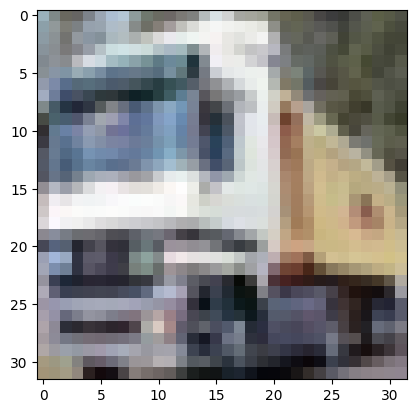

In [9]:
x_train[1,:,:,:]
plt.imshow(x_train[1,:,:,:])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 62s 43ms/step - accuracy: 0.4453 - loss: 1.5219 - val_accuracy: 0.5546 - val_loss: 1.2254
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 59s 42ms/step - accuracy: 0.5849 - loss: 1.1651 - val_accuracy: 0.6280 - val_loss: 1.0366
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 82s 43ms/step - accuracy: 0.6415 - loss: 1.0178 - val_accuracy: 0.6408 - val_loss: 1.0001
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 81s 42ms/step - accuracy: 0.6788 - loss: 0.9167 - val_accuracy: 0.6640 - val_loss: 0.9629
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 83s 43ms/step - accuracy: 0.7039 - loss: 0.8414 - val_accuracy: 0.7018 - val_loss: 0.8650
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 62s 44ms/step - accuracy: 0.7254 - loss: 0.7836 - val_accuracy: 0.7076 - val_loss: 0.8627
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 59s 42ms/step - accuracy: 0.7427 - loss: 0.7305 - val_accuracy: 0.7080 - val_loss: 0.8516
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 84s 43ms/step - accuracy: 0.7590 -

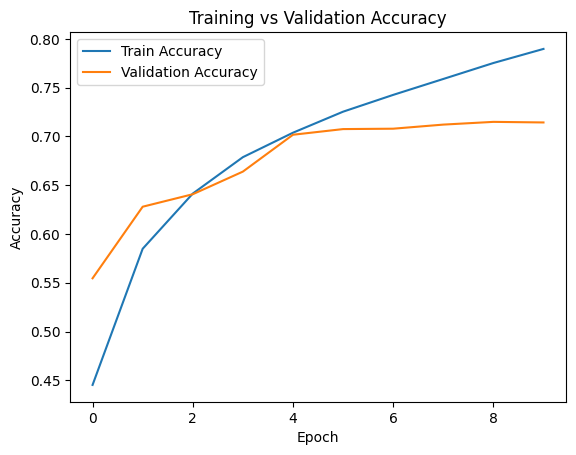

In [ ]:
# Step 2: Normalize pixel values
x_train, x_test = x_train / 255.0, x_test / 255.0

# Step 3: Define class names
class_names = [
    'airplane', 'car', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# Step 4: Build the CNN model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Step 5: Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Step 6: Train the model
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_split=0.1
)

# Step 7: Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

# Step 8: Plot accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()